# Hybrid glider as a Strong Stackelberg Security Game (SSG)

This notebook lifts the single-agent hybrid-glider trajectory optimizer
(`hybrid_glider_corrected.ipynb`) into a **non-zero-sum Strong Stackelberg
Security Game** for the airport-perimeter defense scenario.

**Leader (defender).** Places a single co-located radar + acoustic sensor at a
site $z_d$ drawn from a perimeter-constrained candidate set $D$. Objective
$J_D = \beta_1 P_D + \beta_2\,\mathrm{Coverage}$ (maximize).

**Follower (attacker).** A boost-glide vehicle launched from the origin that must
reach the airport at the goal. It solves a hybrid optimal-control problem
(powered phase, then a glide phase) and best-responds to the placement by
choosing its phase-switch point and trajectory. Objective
$J_A = \alpha_1 P_D + \alpha_2 T$ (minimize).

**Solution concept.** Strong Stackelberg Equilibrium (SSE), computed by
**deterministic enumeration** over $D$: for each placement we compute the
attacker best response; ties in the follower's objective are broken in the
leader's favor (the "strong" rule).

## What is reused vs. new (relative to the corrected notebook)

- **Reused unchanged:** point-mass dynamics + RK4, the state grids and snapping,
  the clearance/flare floor, the energy-optimal **powered DP** (it is
  detection-independent, so it is solved **once** and reused for every placement),
  the regularized **glide DP**, and the smooth trajectory reconstruction.
- **New / corrected:**
  1. **Sensor decoupled from the switch.** The radar/acoustic site is now an
     independent leader decision $z_d$, not `0.5*(z_sw + Z_GOAL)`.
  2. **Range-dependent threat model with Poisson fusion.** Doppler
     $\lambda v_r^2/r^4$ and RCS $\lambda\sigma(\gamma)/r^4$ (both phases),
     acoustic $\lambda v^n/r^2$ (powered phase only). Intensities are summed and
     $P_D = 1 - \exp(-\!\int\!\sum_k \lambda_k\,\mathrm{d}t)$.
  3. **Explicit follower oracle** `attacker_BR(sensor)` minimizing
     $\alpha_1 P_D + \alpha_2 T$ with the strong tie-break.
  4. **Leader** with placement set $D$, a coverage term, and $J_D$.
  5. **SSE enumeration** plus naive (central) and greedy (coverage-max) baselines,
     and the headline three-way comparison figure.

Typical end-to-end runtime is about 3 to 4 minutes.

In [1]:
import math, time, heapq
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Scalar math uses the `math` module (not numpy) inside the DP inner loops;
# this is roughly 1.5x faster than numpy scalar trig and matters a lot here.

## Constants, vehicle, mission, defender, threat, objectives

The airport asset sits at the goal. The defender may place its sensor anywhere on
the candidate set `D_SITES` inside the perimeter radius `R_PERIM` (ground sites,
$h=0$). The detection intensities are calibrated so the realized $P_D$ against the
best-responding attacker spans a usable band rather than saturating at 1.

In [2]:
# --- physics / vehicle ---
G, RHO = 9.81, 1.225
M, S, CD = 1.5, 0.1, 0.025
CL_DISCRETE = tuple(np.linspace(0.1, 1.5, 10))      # lift-coefficient control set
V_STALL, V_MAX = 14.0, 100.0
T_MAX = 25.0
THRUST_LEVELS = (0.0, T_MAX)                         # bang-bang thrust control

# --- mission geometry ---
Z_LAUNCH, H_LAUNCH = 0.0, 0.0
V_LAUNCH, GAM_LAUNCH = V_STALL, math.radians(45.0)   # 45 deg catapult launch
Z_GOAL, H_GOAL = 2500.0, 0.0                         # airport asset at the goal
DT_GLIDE, DT_POW = 1.0, 0.25
V_MAX_GLIDE = 60.0

# --- DEFENDER (leader): co-located radar + acoustic on ONE perimeter site ---
R_PERIM     = 2000.0                                       # airport perimeter radius (m)
D_SITES     = np.arange(Z_GOAL - R_PERIM, Z_GOAL + 1, 250.0)   # candidate sites z_d (h=0)
CORRIDOR_Z0 = 500.0                                        # approach corridor [z0, goal]
R_DET       = 600.0                                        # nominal coverage radius (m)

# --- threat model (Poisson intensities; radar r^-4, acoustic r^-2) ---
LAM_DOPPLER  = 1.5e4    # doppler:  lam * v_r^2 / r^4   (both phases)
LAM_RCS      = 2.0e5    # rcs:      lam * sigma(gamma) / r^4   (both phases)
SIGMA0, SIGMA_MIN = 1.0, 0.1
LAM_ACOUSTIC = 0.08     # acoustic: lam * v^n / r^2     (powered phase, T>0 only)
N_ACOUSTIC   = 4        # speed exponent (4-6 typical for propulsion noise)
R_FLOOR      = 10.0     # min range to bound the r^-4 / r^-2 terms

# --- objectives (non-zero-sum) ---
A1_PD, A2_T   = 1.0, 0.002     # attacker  J_A = A1*P_D + A2*T          (minimize)
B1_PD, B2_COV = 1.0, 0.5       # defender  J_D = B1*P_D + B2*Coverage   (maximize)

# --- glide cost shaping ---
W_TIME_GLIDE = 0.005     # small time weight: breaks far-field flat-cost ties
W_SMOOTH     = 2.0       # penalty on |d gamma| per step (rad)
W_SPEED      = 1.5       # penalty on |d v| per step -> damps the phugoid
H_CLEAR      = 15.0      # interior clearance floor (m)
Z_FLARE      = 300.0     # clearance ramps 15 m -> 0 over the last 300 m
H_HEADROOM_G = 100.0     # how far above the switch altitude the glide may zoom

# --- powered cost ---
W_TIME_POW, W_FUEL_POW = 1.0, 0.1

# --- best-response / SSE controls ---
V_SW_FLOOR = 16.0        # ignore near-stall handoffs (cannot glide to goal)
N_SWITCH   = 7           # switch candidates evaluated per placement
TIE_EPS    = 0.01        # follower indifference band on J_A (strong tie-break)

# --- state-grid resolutions (dz, dh in m; dv in m/s; dgam in rad) ---
RANK_GRID  = dict(dz=75.0, dh=8.0, dv=3.0, dgam=math.radians(3.0))   # SSE sweep (selection)
FINAL_GRID = dict(dz=50.0, dh=5.0, dv=2.0, dgam=math.radians(2.0))   # reported metrics

## Dynamics

Standard point-mass longitudinal model. Thrust `T` acts along the flight path and
enters only the speed equation; the nose is pitched aerodynamically through `CL`.
With `T = 0` this is the glide model.

In [3]:
def eom(v, gamma, CL, T):
    '''Returns (zdot, hdot, vdot, gammadot).'''
    s, co = math.sin(gamma), math.cos(gamma)
    q = 0.5 * RHO * v * v * S
    return (v * co,
            v * s,
            -G * s - q * CD / M + T / M,
            q * CL / (M * v) - G * co / v)

def rk4(z, h, v, gamma, CL, dt, T):
    '''One RK4 step with control (CL, T) held constant over dt.'''
    k1 = eom(v, gamma, CL, T)
    k2 = eom(v + k1[2]*dt/2, gamma + k1[3]*dt/2, CL, T)
    k3 = eom(v + k2[2]*dt/2, gamma + k2[3]*dt/2, CL, T)
    k4 = eom(v + k3[2]*dt,   gamma + k3[3]*dt,   CL, T)
    return (z + dt/6*(k1[0] + 2*k2[0] + 2*k3[0] + k4[0]),
            h + dt/6*(k1[1] + 2*k2[1] + 2*k3[1] + k4[1]),
            v + dt/6*(k1[2] + 2*k2[2] + 2*k3[2] + k4[2]),
            gamma + dt/6*(k1[3] + 2*k2[3] + 2*k3[3] + k4[3]))

## Threat model (range-dependent, Poisson fusion)

Each sensor channel contributes a detection **intensity** (rate):

- Doppler: $\lambda_\mathrm{dop}\, v_r^2 / r^4$ (both phases), $v_r$ = radial speed.
- RCS: $\lambda_\mathrm{rcs}\, \sigma(\gamma) / r^4$ (both phases),
  $\sigma(\gamma) = \sigma_\mathrm{min} + (\sigma_0-\sigma_\mathrm{min})\cos^2(\text{aspect})$.
- Acoustic: $\lambda_\mathrm{ac}\, v^n / r^2$ (powered phase only, motor on).

Under independent-Poisson fusion the intensities **add**, so the cumulative hazard
is $H=\int \sum_k \lambda_k\,\mathrm{d}t$ and $P_D = 1-e^{-H}$. The DP minimizes the
hazard (the exponent), which is monotone in $P_D$.

In [4]:
def _range(z, h, sensor):
    r = math.hypot(z - sensor[0], h - sensor[1])
    return r if r > R_FLOOR else R_FLOOR

def doppler_rate(z, h, v, gamma, sensor):
    r = _range(z, h, sensor)
    dz, dh = z - sensor[0], h - sensor[1]
    vr = (v*math.cos(gamma)*dz + v*math.sin(gamma)*dh) / r     # radial velocity
    return LAM_DOPPLER * vr*vr / r**4

def rcs_rate(z, h, v, gamma, sensor):
    r = _range(z, h, sensor)
    ez, eh = (sensor[0]-z)/r, (sensor[1]-h)/r
    c = ez*(-math.sin(gamma)) + eh*math.cos(gamma)             # aspect projection
    sigma = SIGMA_MIN + (SIGMA0 - SIGMA_MIN) * c*c
    return LAM_RCS * sigma / r**4

def radar_rate(z, h, v, gamma, sensor):
    return doppler_rate(z, h, v, gamma, sensor) + rcs_rate(z, h, v, gamma, sensor)

def acoustic_rate(z, h, v, sensor):
    r = _range(z, h, sensor)
    return LAM_ACOUSTIC * v**N_ACOUSTIC / (r*r)

def hazard_glide(pts, sensor, dt_sub):
    '''Radar hazard integrated over a glide trajectory (5-tuples).'''
    return sum(radar_rate(z, h, v, g, sensor)*dt_sub for (z, h, v, g, _T) in pts[:-1])

def hazard_powered(pts, sensor, dt_sub):
    '''Radar (both phases) + acoustic (T>0 only) over a powered trajectory.'''
    cost = 0.0
    for (z, h, v, g, T) in pts[:-1]:
        cost += radar_rate(z, h, v, g, sensor) * dt_sub
        if T > 0:
            cost += acoustic_rate(z, h, v, sensor) * dt_sub
    return cost

def pod_from_hazard(hz):
    return 1.0 - math.exp(-hz)

## State grids, snapping, and the ground-clearance floor

The glide speed grid is capped at `V_MAX_GLIDE`. The clearance floor is a fixed
height `hc` that ramps linearly to zero over the last `zf` metres before the goal,
allowing a clean flare to touchdown.

In [5]:
def glide_grid(z_sw, h_sw, dz, dh, dv, dgam, hh):
    Z = np.arange(z_sw, Z_GOAL + dz, dz)
    H = np.arange(0.0, h_sw + hh + dh, dh)
    Vv = np.arange(V_STALL, V_MAX_GLIDE + dv, dv)
    Gg = np.arange(math.radians(-90), math.radians(45) + dgam, dgam)
    return dict(Z0=Z[0], H0=H[0], V0=Vv[0], G0=Gg[0],
                dz=dz, dh=dh, dv=dv, dgam=dgam,
                NZ=len(Z), NH=len(H), NV=len(Vv), NG=len(Gg),
                Gam=Gg, V=Vv, Z=Z, H=H)

def pow_grid(dz, dh, dv, dgam, zmax, hmax):
    Z = np.arange(0.0, zmax + dz, dz)
    H = np.arange(0.0, hmax + dh, dh)
    Vv = np.arange(V_STALL, V_MAX + dv, dv)
    Gg = np.arange(math.radians(-90), math.radians(90) + dgam, dgam)
    return dict(Z0=Z[0], H0=H[0], V0=Vv[0], G0=Gg[0],
                dz=dz, dh=dh, dv=dv, dgam=dgam,
                NZ=len(Z), NH=len(H), NV=len(Vv), NG=len(Gg),
                Gam=Gg, V=Vv, Z=Z, H=H)

def snap(gr, z, h, v, gamma):
    '''Nearest grid index, or None if out of bounds.'''
    iz = int(round((z - gr['Z0']) / gr['dz']))
    ih = int(round((h - gr['H0']) / gr['dh']))
    iv = int(round((v - gr['V0']) / gr['dv']))
    ig = int(round((gamma - gr['G0']) / gr['dgam']))
    if 0 <= iz < gr['NZ'] and 0 <= ih < gr['NH'] and 0 <= iv < gr['NV'] and 0 <= ig < gr['NG']:
        return (iz, ih, iv, ig)
    return None

def minclear(z, hc, zf):
    '''Minimum allowed altitude at range z: hc, ramping to 0 over the last zf m.'''
    d = Z_GOAL - z
    if d >= zf: return hc
    if d <= 0:  return 0.0
    return hc * d / zf

## Powered phase: Dijkstra DP (energy-only, solved once)

Forward Dijkstra from the launch state with control `(CL, T)` and cost
`w_time*dt + w_fuel*T*dt`. The powered cost does **not** depend on the sensor
placement, so this DP is solved a **single time** and reused for every defender
site. `handoff_at` returns the cheapest arrival at a switch cell subject to the
hard descending-handoff guard `gamma_sw <= 0`.

In [6]:
def powered_dp(gr, w_time, w_fuel):
    s0 = snap(gr, Z_LAUNCH, H_LAUNCH, V_LAUNCH, GAM_LAUNCH)
    V = {s0: 0.0}; prev = {}; cont = {s0: (Z_LAUNCH, H_LAUNCH, V_LAUNCH, GAM_LAUNCH)}
    heap = [(0.0, 0, s0)]; cnt = 1; hmax = gr['H'][-1]
    while heap:
        c, _, s = heapq.heappop(heap)
        if c > V.get(s, 1e18) + 1e-9: continue
        z, h, v, gm = cont[s]
        for T in THRUST_LEVELS:
            base = w_time * DT_POW + w_fuel * T * DT_POW
            for CL in CL_DISCRETE:
                zn, hn, vn, gn = rk4(z, h, v, gm, CL, DT_POW, T)
                if hn < 0 or zn < 0 or vn < V_STALL or hn > hmax: continue
                sn = snap(gr, zn, hn, vn, gn)
                if sn is None: continue
                nc = c + base
                if nc < V.get(sn, 1e18):
                    V[sn] = nc; prev[sn] = (s, CL, T); cont[sn] = (zn, hn, vn, gn)
                    heapq.heappush(heap, (nc, cnt, sn)); cnt += 1
    return V, prev, cont, s0

def handoff_at(gr, V, cont, z_sw, h_sw):
    '''Cheapest powered arrival at (z_sw, h_sw) with gamma_sw <= 0 (hard guard).'''
    izp = int(round((z_sw - gr['Z0']) / gr['dz']))
    ihp = int(round((h_sw - gr['H0']) / gr['dh']))
    if not (0 <= izp < gr['NZ'] and 0 <= ihp < gr['NH']): return None
    best, bv = None, 1e18
    for iv in range(gr['NV']):
        for ig in range(gr['NG']):
            if gr['Gam'][ig] > 1e-9: continue          # enforce descending handoff
            s = (izp, ihp, iv, ig)
            if s in V and V[s] < bv: bv, best = V[s], s
    if best is None: return None
    z, h, v, g = cont[best]
    return dict(state=best, v=v, gamma=g, cost=bv)

## Glide phase: regularized Dijkstra DP against a fixed sensor

Forward Dijkstra from the handoff state. Step cost:

`radar_rate(state, sensor)*dt + w_time*dt + w_smooth*|d gamma| + w_speed*|d v|`.

The sensor position is now passed in explicitly (the leader's decision). The
`w_speed` term damps the phugoid. The clearance floor is enforced on every
transition, and the first goal-cell state popped is optimal (non-negative costs).

In [7]:
def glide_dp(gr, z_sw, h_sw, v_sw, g_sw, sensor, w_time, w_smooth, w_speed, hc, zf, hh,
             use_radar=True):
    '''use_radar=False yields a detection-blind glide (for the greedy/non-adaptive baseline).'''
    s0 = snap(gr, z_sw, h_sw, v_sw, g_sw)
    if s0 is None: return None
    izg = gr['NZ'] - 1
    V = {s0: 0.0}; prev = {}; cont = {s0: (z_sw, h_sw, v_sw, g_sw)}
    heap = [(0.0, 0, s0)]; cnt = 1; ceil = h_sw + hh; goal = None
    while heap:
        c, _, s = heapq.heappop(heap)
        if c > V.get(s, 1e18) + 1e-9: continue
        if s[0] == izg and s[1] == 0: goal = s; break
        z, h, v, gm = cont[s]
        pr = radar_rate(z, h, v, gm, sensor) if use_radar else 0.0
        for CL in CL_DISCRETE:
            zn, hn, vn, gn = rk4(z, h, v, gm, CL, DT_GLIDE, 0.0)
            if zn < z_sw or vn < V_STALL or hn > ceil: continue
            if hn < minclear(zn, hc, zf) - 1e-9: continue
            sn = snap(gr, zn, hn, vn, gn)
            if sn is None: continue
            nc = c + pr*DT_GLIDE + w_time*DT_GLIDE + w_smooth*abs(gn - gm) + w_speed*abs(vn - v)
            if nc < V.get(sn, 1e18):
                V[sn] = nc; prev[sn] = (s, CL); cont[sn] = (zn, hn, vn, gn)
                heapq.heappush(heap, (nc, cnt, sn)); cnt += 1
    return V, prev, cont, s0, goal

## Smooth trajectory reconstruction

Replay the stored control sequence from the continuous start state with
sub-stepping, giving a smooth, dynamically consistent path for both phases.
Reconstructed points are 5-tuples `(z, h, v, gamma, T)` so the acoustic gate
(`T>0`) is available downstream.

In [8]:
def reconstruct(prev, cont, s_goal, s0, dt, T_is_stored, substeps=8):
    seq = []; s = s_goal
    while s != s0 and s in prev:
        e = prev[s]
        if T_is_stored: ps, CL, Tt = e
        else:           ps, CL = e; Tt = 0.0
        seq.append((CL, Tt)); s = ps
    seq.reverse()
    z, h, v, g = cont[s0]; sub = dt / substeps
    pts = [(z, h, v, g, 0.0)]
    for CL, Tt in seq:
        for _ in range(substeps):
            z, h, v, g = rk4(z, h, v, g, CL, sub, Tt)
            pts.append((z, h, v, g, Tt))
    return pts

def count_steps(prev, s0, s_goal):
    n, s = 0, s_goal
    while s != s0 and s in prev:
        n += 1; s = prev[s][0]
    return n

## Follower oracle: attacker best response $\mathrm{BR}(z_d)$

Given a fixed sensor, enumerate the feasible phase-switch candidates, solve the
glide phase for each, integrate the full-flight hazard (powered radar + acoustic,
glide radar), and return the switch minimizing $J_A=\alpha_1P_D+\alpha_2T$.

**Strong-Stackelberg tie-break:** among switches within `TIE_EPS` of the minimum
$J_A$, the follower selects the one **most favorable to the leader** (highest
$P_D$). This is what distinguishes SSE from weak Stackelberg.

In [9]:
def switch_candidates(grp, Vp, contp):
    raw = []
    for z_sw in np.arange(100.0, 300.0 + 1, 50.0):
        for h_sw in np.arange(40.0, 160.0 + 1, 20.0):
            ho = handoff_at(grp, Vp, contp, z_sw, h_sw)
            if ho is None or ho['v'] < V_SW_FLOOR: continue
            raw.append((z_sw, h_sw, ho))
    if len(raw) > N_SWITCH:
        idx = np.linspace(0, len(raw) - 1, N_SWITCH).round().astype(int)
        return [raw[i] for i in sorted(set(idx))]
    return raw

def attacker_BR(sensor, grp, Vp, prevp, contp, s0p, cands, grid=None, substeps=6,
                use_radar=True):
    '''Best response to a fixed sensor. Returns the chosen switch, its trajectories,
    P_D, T, J_A, and hazard. Strong tie-break favors the leader.'''
    grid = grid or RANK_GRID
    evals = []
    for z_sw, h_sw, ho in cands:
        gr = glide_grid(z_sw, h_sw, hh=H_HEADROOM_G, **grid)
        out = glide_dp(gr, z_sw, h_sw, ho['v'], ho['gamma'], sensor,
                       W_TIME_GLIDE, W_SMOOTH, W_SPEED, H_CLEAR, Z_FLARE, H_HEADROOM_G,
                       use_radar=use_radar)
        if out is None: continue
        V, prev, cont, s0, best = out
        if best is None: continue
        glide_pts = reconstruct(prev, cont, best, s0, DT_GLIDE, False, substeps=substeps)
        pow_pts   = reconstruct(prevp, contp, ho['state'], s0p, DT_POW, True, substeps=substeps)
        hz = (hazard_glide(glide_pts, sensor, DT_GLIDE/substeps)
              + hazard_powered(pow_pts, sensor, DT_POW/substeps))
        P_D = pod_from_hazard(hz)
        T = (count_steps(prevp, s0p, ho['state'])*DT_POW
             + count_steps(prev, s0, best)*DT_GLIDE)
        J_A = A1_PD*P_D + A2_T*T
        evals.append(dict(J_A=J_A, P_D=P_D, T=T, hz=hz, z_sw=z_sw, h_sw=h_sw,
                          ho=ho, glide_pts=glide_pts, pow_pts=pow_pts))
    if not evals: return None
    jmin = min(e['J_A'] for e in evals)
    tied = [e for e in evals if e['J_A'] <= jmin + TIE_EPS]
    return max(tied, key=lambda e: e['P_D'])     # leader-favorable tie-break

## Leader: coverage and the defender objective

`coverage` is the fraction of the approach corridor $[\,$`CORRIDOR_Z0`$,\,$`Z_GOAL`$\,]$
that falls within the sensor's nominal range `R_DET`. The defender maximizes
$J_D=\beta_1 P_D + \beta_2\,\mathrm{Coverage}$, where $P_D$ is evaluated **against
the attacker's best response** to the placement.

In [10]:
def coverage(sensor):
    lo = max(CORRIDOR_Z0, sensor[0] - R_DET)
    hi = min(Z_GOAL,      sensor[0] + R_DET)
    return max(0.0, hi - lo) / (Z_GOAL - CORRIDOR_Z0)

def J_D(P_D, sensor):
    return B1_PD * P_D + B2_COV * coverage(sensor)

## Step 1: solve the powered phase once

In [11]:
t0 = time.time()
grp = pow_grid(dz=25.0, dh=10.0, dv=3.0, dgam=math.radians(4.0), zmax=300.0, hmax=200.0)
Vp, prevp, contp, s0p = powered_dp(grp, W_TIME_POW, W_FUEL_POW)
cands = switch_candidates(grp, Vp, contp)
print(f'powered DP (solved once): {len(Vp)} states in {time.time()-t0:.1f} s')
print(f'feasible switch candidates: {len(cands)}')

powered DP (solved once): 109284 states in 11.8 s
feasible switch candidates: 7


## Step 2: SSE enumeration over the defender placement set

For each candidate site we compute the attacker best response on the
**ranking grid** and score the placement by $J_D$. The leader's SSE placement is
the argmax. This is a deterministic enumeration: no Monte Carlo, no iterated
best-response loop (the Stackelberg structure removes it).

In [12]:
t0 = time.time()
sweep = []
print(f'{"z_d":>6} {"hazard":>8} {"P_D":>7} {"T":>7} {"cov":>6} {"J_D":>7}   switch')
for zd in D_SITES:
    sensor = (float(zd), 0.0)
    br = attacker_BR(sensor, grp, Vp, prevp, contp, s0p, cands)     # ranking grid
    if br is None:
        print(f'{zd:6.0f}  (no reachable best response)'); continue
    jd = J_D(br['P_D'], sensor)
    sweep.append(dict(zd=float(zd), sensor=sensor, P_D=br['P_D'], T=br['T'],
                      cov=coverage(sensor), J_D=jd, br=br))
    print(f'{zd:6.0f} {br["hz"]:8.3f} {br["P_D"]:7.3f} {br["T"]:7.1f} '
          f'{coverage(sensor):6.2f} {jd:7.3f}   ({br["z_sw"]:.0f},{br["h_sw"]:.0f})')

sse    = max(sweep, key=lambda r: r['J_D'])                 # game-aware (SSE)
naive  = next(r for r in sweep if r['zd'] == float(D_SITES[len(D_SITES)//2]))  # central
greedy = max(sweep, key=lambda r: (r['cov'], -r['zd']))     # coverage-myopic (ties -> nearer)
print(f'\nSSE sweep over {len(sweep)} placements in {time.time()-t0:.1f} s')
print(f'SSE    (game-aware) : z_d={sse["zd"]:.0f}  J_D={sse["J_D"]:.3f}  P_D={sse["P_D"]:.3f}')
print(f'Naive  (central)    : z_d={naive["zd"]:.0f}  J_D={naive["J_D"]:.3f}  P_D={naive["P_D"]:.3f}')
print(f'Greedy (coverage)   : z_d={greedy["zd"]:.0f}  J_D={greedy["J_D"]:.3f}  P_D={greedy["P_D"]:.3f}')

   z_d   hazard     P_D       T    cov     J_D   switch
   500    2.347   0.904   112.5   0.30   1.054   (250,120)
   750    1.052   0.651   112.5   0.42   0.863   (250,120)
  1000    0.694   0.500   112.5   0.55   0.775   (250,120)
  1250    0.637   0.471   110.5   0.60   0.771   (250,120)
  1500    0.851   0.573   110.5   0.60   0.873   (250,120)
  1750    0.573   0.436   106.2   0.60   0.736   (300,160)
  2000    2.201   0.889   103.2   0.55   1.164   (300,160)
  2250    2.994   0.950   106.2   0.42   1.162   (300,160)
  2500    2.629   0.928   109.5   0.30   1.078   (250,120)

SSE sweep over 9 placements in 52.7 s
SSE    (game-aware) : z_d=2000  J_D=1.164  P_D=0.889
Naive  (central)    : z_d=1500  J_D=0.873  P_D=0.573
Greedy (coverage)   : z_d=1250  J_D=0.771  P_D=0.471


## Step 3: re-evaluate the three strategies on the fine grid

Selection used the coarse ranking grid for speed. We now recompute the attacker
best response at the three chosen placements on the finer `FINAL_GRID` and report
those metrics consistently in the figure and table.

In [13]:
def fine_eval(rec):
    br = attacker_BR(rec['sensor'], grp, Vp, prevp, contp, s0p, cands,
                     grid=FINAL_GRID, substeps=10)
    return dict(rec, P_D=br['P_D'], T=br['T'], J_D=J_D(br['P_D'], rec['sensor']), br=br)

t0 = time.time()
sse_f, naive_f, greedy_f = fine_eval(sse), fine_eval(naive), fine_eval(greedy)
print(f'fine re-evaluation of 3 strategies in {time.time()-t0:.1f} s')
for name, r in [('SSE', sse_f), ('Naive', naive_f), ('Greedy', greedy_f)]:
    print(f'{name:7s} z_d={r["zd"]:.0f}  P_D={r["P_D"]:.3f}  cov={r["cov"]:.2f}  J_D={r["J_D"]:.3f}')

fine re-evaluation of 3 strategies in 68.8 s
SSE     z_d=2000  P_D=0.962  cov=0.55  J_D=1.237
Naive   z_d=1500  P_D=0.602  cov=0.60  J_D=0.902
Greedy  z_d=1250  P_D=0.555  cov=0.60  J_D=0.855


## Step 4: headline figure

Left: leader payoff $J_D$ over the placement set (the SSE selection), with $P_D$
and coverage. Middle: the attacker's best-response trajectory at the SSE placement
(the phase-switching visualization). Right: the three-way comparison of
game-aware vs. naive vs. greedy.

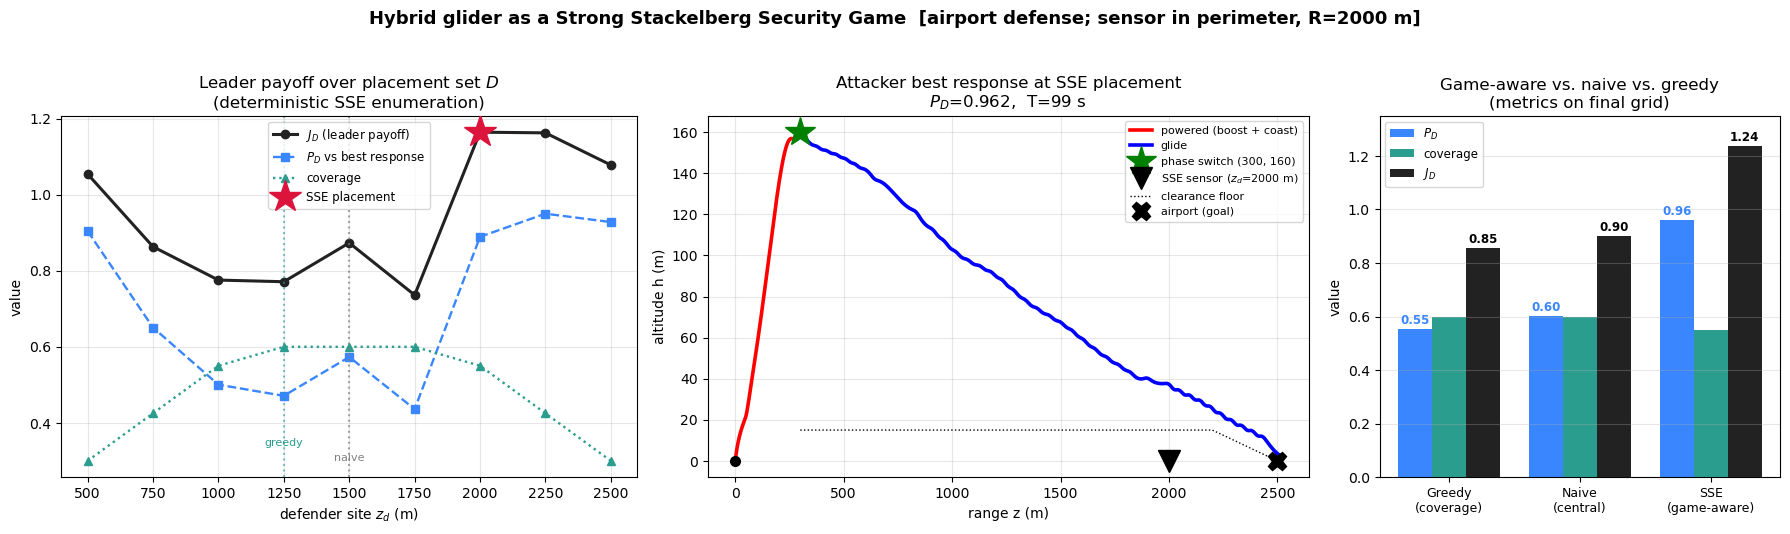

In [14]:
NA_C, AC_C, COV_C = '#E07B39', '#3A86FF', '#2a9d8f'
fig, ax = plt.subplots(1, 3, figsize=(18, 5.4),
                       gridspec_kw={'width_ratios': [2.3, 2.4, 1.6]})
fig.suptitle('Hybrid glider as a Strong Stackelberg Security Game  '
             f'[airport defense; sensor in perimeter, R={R_PERIM:.0f} m]',
             fontsize=13, fontweight='bold')

# --- Panel A: leader payoff over placement set D (ranking-grid sweep) ---
zds = [r['zd'] for r in sweep]
ax[0].plot(zds, [r['J_D'] for r in sweep], 'o-', color='#222', lw=2.2, label=r'$J_D$ (leader payoff)')
ax[0].plot(zds, [r['P_D'] for r in sweep], 's--', color=AC_C, lw=1.7, label=r'$P_D$ vs best response')
ax[0].plot(zds, [r['cov'] for r in sweep], '^:', color=COV_C, lw=1.7, label='coverage')
ax[0].plot(sse['zd'], sse['J_D'], '*', color='crimson', ms=24, zorder=6, label='SSE placement')
ax[0].axvline(naive['zd'],  color='gray',  ls=':', alpha=0.7)
ax[0].axvline(greedy['zd'], color=COV_C,   ls=':', alpha=0.6)
ax[0].annotate('naive', (naive['zd'], 0.30), color='gray', fontsize=8, ha='center')
ax[0].annotate('greedy', (greedy['zd'], 0.34), color=COV_C, fontsize=8, ha='center')
ax[0].set_xlabel(r'defender site $z_d$ (m)'); ax[0].set_ylabel('value')
ax[0].set_title('Leader payoff over placement set $D$\n(deterministic SSE enumeration)')
ax[0].legend(fontsize=8.5, loc='upper center'); ax[0].grid(alpha=0.3)

# --- Panel B: SSE attacker best-response trajectory (phase-switch viz) ---
brf = sse_f['br']; zd = sse_f['zd']
pz = [p[0] for p in brf['pow_pts']];  ph = [p[1] for p in brf['pow_pts']]
gz = [p[0] for p in brf['glide_pts']]; gh = [p[1] for p in brf['glide_pts']]
ax[1].plot(pz, ph, 'r-', lw=2.6, label='powered (boost + coast)')
ax[1].plot(gz, gh, 'b-', lw=2.6, label='glide')
ax[1].plot(brf['z_sw'], brf['h_sw'], 'g*', ms=22, zorder=6,
           label=f'phase switch ({brf["z_sw"]:.0f}, {brf["h_sw"]:.0f})')
ax[1].plot(zd, 0, 'kv', ms=16, zorder=6, label=f'SSE sensor ($z_d$={zd:.0f} m)')
zf = np.linspace(brf['z_sw'], Z_GOAL, 250)
ax[1].plot(zf, [minclear(z, H_CLEAR, Z_FLARE) for z in zf], 'k:', lw=1, label='clearance floor')
ax[1].plot(0, 0, 'ko', ms=7); ax[1].plot(Z_GOAL, 0, 'kX', ms=13, label='airport (goal)')
ax[1].set_xlabel('range z (m)'); ax[1].set_ylabel('altitude h (m)')
ax[1].set_title(f'Attacker best response at SSE placement\n'
                f'$P_D$={sse_f["P_D"]:.3f},  T={sse_f["T"]:.0f} s')
ax[1].legend(fontsize=8, loc='upper right'); ax[1].grid(alpha=0.3)

# --- Panel C: game-aware vs naive vs greedy ---
strat = [('Greedy\n(coverage)', greedy_f), ('Naive\n(central)', naive_f), ('SSE\n(game-aware)', sse_f)]
x = np.arange(3); w = 0.26
ax[2].bar(x - w, [s[1]['P_D'] for s in strat], w, label=r'$P_D$',     color=AC_C)
ax[2].bar(x,     [s[1]['cov'] for s in strat], w, label='coverage',   color=COV_C)
ax[2].bar(x + w, [s[1]['J_D'] for s in strat], w, label=r'$J_D$',     color='#222')
for i, s in enumerate(strat):
    ax[2].text(i - w, s[1]['P_D'] + 0.02, f"{s[1]['P_D']:.2f}", ha='center', fontsize=8.5, color=AC_C, fontweight='bold')
    ax[2].text(i + w, s[1]['J_D'] + 0.02, f"{s[1]['J_D']:.2f}", ha='center', fontsize=8.5, fontweight='bold')
ax[2].set_xticks(x); ax[2].set_xticklabels([s[0] for s in strat], fontsize=9)
ax[2].set_ylabel('value'); ax[2].set_ylim(0, 1.35)
ax[2].set_title('Game-aware vs. naive vs. greedy\n(metrics on final grid)')
ax[2].legend(fontsize=8.5, loc='upper left'); ax[2].grid(alpha=0.3, axis='y')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [15]:
# --- Summary table (final-grid metrics) ---
print(f'{"Strategy":<18}{"z_d (m)":>9}{"P_D":>9}{"coverage":>10}{"J_D":>9}{"T (s)":>9}')
print('-' * 64)
for name, r in [('Greedy (coverage)', greedy_f), ('Naive (central)', naive_f), ('SSE (game-aware)', sse_f)]:
    print(f'{name:<18}{r["zd"]:>9.0f}{r["P_D"]:>9.3f}{r["cov"]:>10.2f}{r["J_D"]:>9.3f}{r["T"]:>9.1f}')
print()
dP = sse_f['P_D'] - greedy_f['P_D']
print(f'SSE vs greedy: P_D {greedy_f["P_D"]:.3f} -> {sse_f["P_D"]:.3f}  (+{dP:.3f}, '
      f'{100*dP/greedy_f["P_D"]:.0f}% higher detection of the best-responding attacker)')

Strategy            z_d (m)      P_D  coverage      J_D    T (s)
----------------------------------------------------------------
Greedy (coverage)      1250    0.555      0.60    0.855     96.2
Naive (central)        1500    0.602      0.60    0.902     96.2
SSE (game-aware)       2000    0.962      0.55    1.237     99.2

SSE vs greedy: P_D 0.555 -> 0.962  (+0.407, 73% higher detection of the best-responding attacker)


## Notes, caveats, and next steps

**The game is non-trivial because of the $r^{-4}$ falloff.** Forward placements
catch the boost acoustically; aft placements catch the unavoidable terminal
approach by radar; central placements are the easiest to evade. The SSE exploits
the chokepoint the follower cannot avoid (the terminal descent to the asset)
rather than spreading raw coverage, which is why the coverage-greedy baseline is
out-detected. The headline message for the GameSec audience is exactly this:
**coverage is not security; anticipating the best-responding attacker changes the
optimal placement.**

**Grids.** Selection uses the coarse ranking grid; the three reported strategies
are re-solved on the finer grid (Step 3). This mirrors the rank/final split of the
single-agent notebook and keeps runtime at lunch-hour scale.

**Powered phase is detection-blind except through the switch.** The powered DP
minimizes energy only; acoustic/radar hazard on the boost is scored post hoc per
switch. A fuller follower would route the boost to dodge a forward acoustic
sensor. Acceptable for this scenario (the perimeter keeps sensors away from the
launch), but worth a sentence in the paper.

**Calibration.** `LAM_DOPPLER`, `LAM_RCS`, `LAM_ACOUSTIC` are set so $P_D$ spans a
usable band; they are not yet tied to physical sensor specs. The TODOs carried
from A1b stand: acoustic $v^n$ UAV citation, the Inanc-2008 RCS form, and the
joint sensor-model writeup.

**Next steps toward submission.** (1) Add the naval picket scenario as a
generalization by swapping `Z_GOAL`, `D_SITES`, and the corridor. (2) Run the
deterministic multi-instance sweep over map seeds for robustness of the SSE
ranking. (3) Foreground SSE / resource allocation / adversarial reasoning in the
prose; keep glider dynamics as follower constraints, since the reviewers are
security game theorists.